# Swiggy Bangalore — Restaurant Data Analysis

**Objective:** Analyze Swiggy restaurant listings across Bangalore to understand the city's food delivery landscape — how ratings are distributed, how price and rating relate, which areas are the most expensive, and which cuisines dominate.

**Research questions:**
1. How are restaurant ratings distributed across the platform?
2. How do rating and cost-for-two vary across Bangalore's key areas (BTM, HSR, Koramangala)?
3. Is there a relationship between price and rating?
4. Which cuisines dominate Bangalore overall and area by area?

## 1. Setup & Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/swiggy_bangalore_outlets.csv')
df.head()

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,₹ 150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,₹ 400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,₹ 126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,₹ 400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,₹ 450


In [2]:
df.shape

(118, 5)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Shop_Name     118 non-null    str  
 1   Cuisine       118 non-null    str  
 2   Location      118 non-null    str  
 3   Rating        118 non-null    str  
 4   Cost_for_Two  118 non-null    str  
dtypes: str(5)
memory usage: 4.7 KB


## 2. Data Cleaning

`df.info()` shows **all 5 columns are stored as text (object)** — including `Rating` and `Cost_for_Two`, which we need as numbers. Inspecting them reveals why:

In [4]:
print('Rating values:', sorted(df['Rating'].unique()))
print('Cost sample:', df['Cost_for_Two'].head(3).tolist())

Rating values: ['--', '3.6', '3.7', '3.8', '3.9', '4', '4.1', '4.2', '4.3', '4.4', '4.5', '4.6', '4.8']
Cost sample: ['₹ 150', '₹ 400', '₹ 126']


Two problems to fix:
1. **`Rating` contains `'--'`** — missing ratings disguised as text. If we carelessly convert these to `0`, they would appear as fake "0-star" restaurants and drag every average down. The correct approach is to convert them to `NaN` (proper missing values).
2. **`Cost_for_Two` has a `₹ ` prefix** — must be stripped before converting to a number.

In [5]:
# Convert Rating to numeric; '--' becomes NaN instead of a fake 0
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Strip the rupee symbol and convert cost to integer
df['Cost_for_Two'] = df['Cost_for_Two'].str.replace('₹', '', regex=False).str.strip().astype(int)

print('Missing ratings:', df['Rating'].isnull().sum())
df[['Rating','Cost_for_Two']].describe()

Missing ratings: 1


,Rating,Cost_for_Two
count,117.000000,118.000000
mean,4.096581,321.008475
std,0.209240,137.286804
min,3.600000,100.000000
25%,4.000000,204.750000
50%,4.100000,300.000000
75%,4.300000,400.000000
max,4.800000,800.000000


In [6]:
# Only a handful of rows lack a rating - drop them
df.dropna(subset=['Rating'], inplace=True)

# Extract the main area from Location ('5th Block, Koramangala' -> 'Koramangala')
df['Area'] = df['Location'].str.split(',').str[-1].str.strip()
df['Area'].value_counts()

Area
Koramangala    64
BTM            35
HSR            17
Jayanagar       1
Name: count, dtype: int64

## 3. Distribution of Ratings

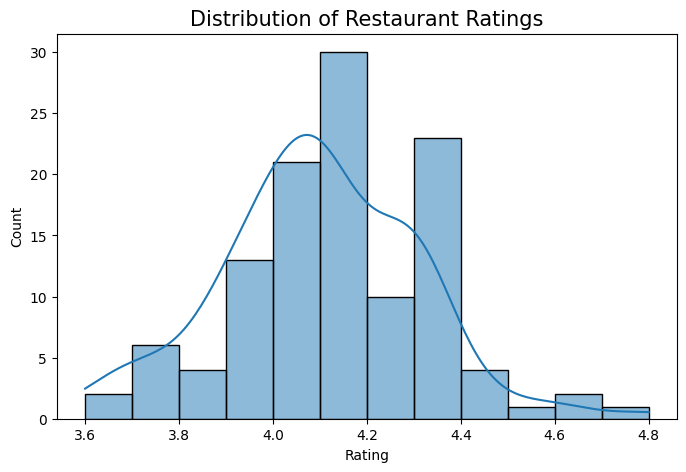

Median rating: 4.1
Share of restaurants rated > 4.1: 35.0 %
Maximum rating: 4.8


In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], kde=True, bins=12)
plt.title('Distribution of Restaurant Ratings', fontsize=15)
plt.xlabel('Rating')
plt.savefig('images/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median rating:', df['Rating'].median())
print('Share of restaurants rated > 4.1:', round((df['Rating'] > 4.1).mean()*100, 1), '%')
print('Maximum rating:', df['Rating'].max())

**Finding:** Ratings cluster tightly between 4.0 and 4.3. Roughly half the restaurants are rated above 4.1, with a maximum of 4.8 — the platform lists generally well-rated outlets.

## 4. Area-wise Analysis: Rating & Cost for Two

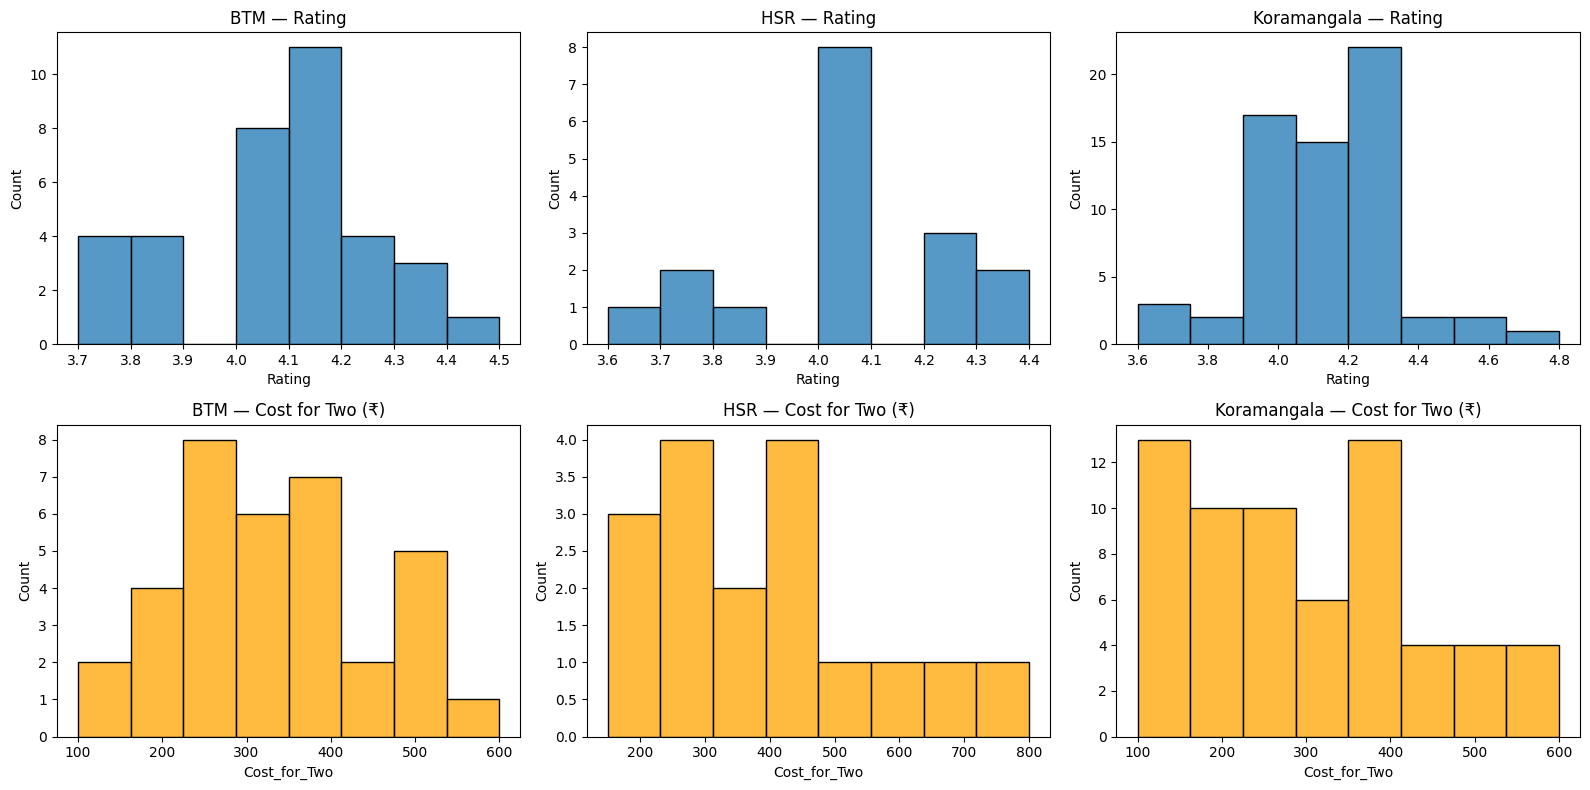

Rating             Cost_for_Two            
              mean median  max         mean median  max
Area                                                   
BTM            4.0    4.1  4.5        329.1  300.0  600
HSR            4.1    4.1  4.4        391.2  350.0  800
Jayanagar      4.3    4.3  4.3        300.0  300.0  300
Koramangala    4.1    4.1  4.8        297.8  254.0  600

In [8]:
areas = ['BTM', 'HSR', 'Koramangala']
fig, axes = plt.subplots(2, 3, figsize=(16,8))
for i, area in enumerate(areas):
    sub = df[df['Area'] == area]
    sns.histplot(sub['Rating'], ax=axes[0][i], bins=8)
    axes[0][i].set_title(f'{area} — Rating')
    sns.histplot(sub['Cost_for_Two'], ax=axes[1][i], bins=8, color='orange')
    axes[1][i].set_title(f'{area} — Cost for Two (₹)')
plt.tight_layout()
plt.show()

df.groupby('Area')[['Rating','Cost_for_Two']].agg(['mean','median','max']).round(1)

**Findings by area:**
- **BTM** — ratings mostly 4.0–4.2; cost for two typically ₹200–350 (max ₹600)
- **HSR** — ratings mostly 4.0+; cost for two typically ₹300–400 (max ₹800) — **the most expensive area**
- **Koramangala** — ratings 4.0–4.3; cost for two typically ₹200–350 (max ₹600)

## 5. Cost vs Rating — Do expensive restaurants earn better ratings?

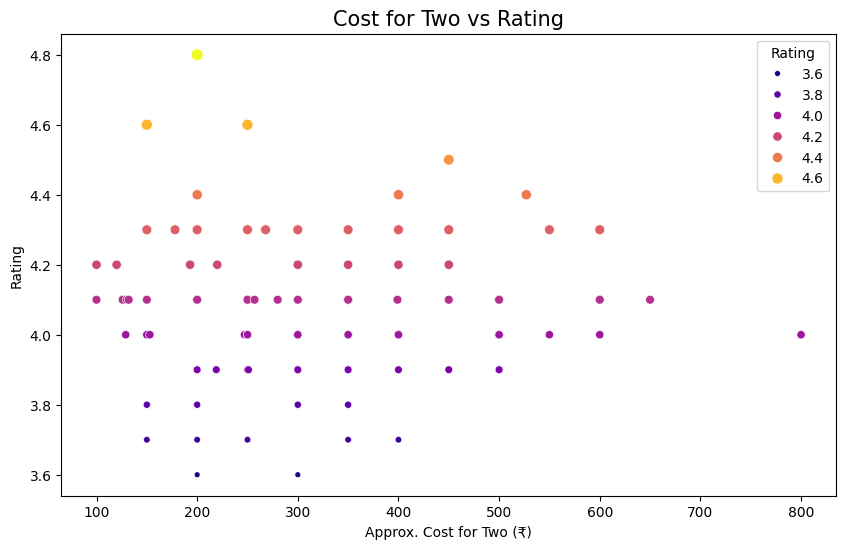

Correlation between cost and rating: 0.038
Top-rated (4.5+) restaurants — average cost: ₹ 262
Restaurants costing 600+ — average rating: 4.13


In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Cost_for_Two', y='Rating', hue='Rating', size='Rating', palette='plasma')
plt.title('Cost for Two vs Rating', fontsize=15)
plt.xlabel('Approx. Cost for Two (₹)')
plt.savefig('images/cost_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation between cost and rating:', df['Cost_for_Two'].corr(df['Rating']).round(3))
print('Top-rated (4.5+) restaurants — average cost: ₹', int(df[df['Rating']>=4.5]['Cost_for_Two'].mean()))
print('Restaurants costing 600+ — average rating:', df[df['Cost_for_Two']>=600]['Rating'].mean().round(2))

**Finding:** Higher price does **not** buy a higher rating. The best-rated restaurants (4.5–4.8) are budget-friendly (₹150–450 for two), while expensive outlets (₹600–800) sit at mediocre 4.0–4.1 ratings. Customers appear to reward affordable, quality food.

## 6. Cuisine Analysis

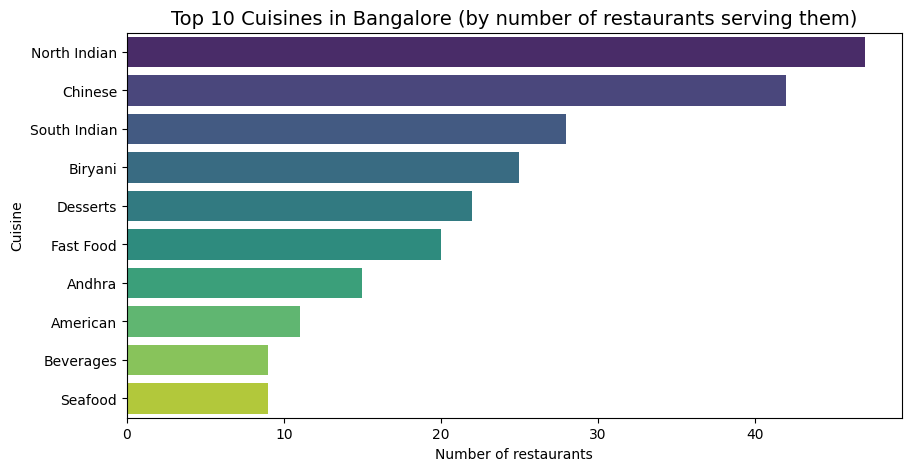

Cuisine
North Indian    14.2
Chinese         12.7
South Indian     8.5
Biryani          7.6
Desserts         6.7
Name: proportion, dtype: float64


In [10]:
# One restaurant lists multiple cuisines - split and explode into individual rows
cuisines = df.assign(Cuisine=df['Cuisine'].str.split(',')).explode('Cuisine')
cuisines['Cuisine'] = cuisines['Cuisine'].str.strip()

top10 = cuisines['Cuisine'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top10.values, y=top10.index, palette='viridis')
plt.title('Top 10 Cuisines in Bangalore (by number of restaurants serving them)', fontsize=14)
plt.xlabel('Number of restaurants')
plt.savefig('images/top_cuisines.png', dpi=150, bbox_inches='tight')
plt.show()

print((cuisines['Cuisine'].value_counts(normalize=True).head(5)*100).round(1))

In [11]:
# Area-wise dominant cuisines
for area in ['BTM','HSR','Koramangala']:
    top3 = cuisines[cuisines['Area']==area]['Cuisine'].value_counts(normalize=True).head(3)*100
    print(f"{area}: " + ", ".join(f"{c} ({p:.1f}%)" for c,p in top3.items()))

BTM: North Indian (16.4%), Chinese (16.4%), South Indian (9.5%)
HSR: North Indian (17.8%), Chinese (11.1%), South Indian (8.9%)
Koramangala: North Indian (12.0%), Chinese (10.8%), South Indian (7.8%)


**Findings:**
- **Chinese, North Indian, and South Indian** dominate Bangalore's Swiggy listings overall
- **BTM & Koramangala**: Chinese leads; **HSR**: North Indian leads — cuisine preference clearly varies by neighborhood

## 7. Budget Champions — Cheapest Highly-Rated Restaurants

In [12]:
budget_best = df[df['Rating'] >= 4.2].nsmallest(10, 'Cost_for_Two')[['Shop_Name','Area','Rating','Cost_for_Two']]
budget_best

,Shop_Name,Area,Rating,Cost_for_Two
79,Tandoori Merchant,BTM,4.2,100
95,NIC Natural Ice Creams,Koramangala,4.2,120
0,Kanti Sweets,Koramangala,4.3,150
24,New Udupi Grand,HSR,4.3,150
82,Natural Ice Cream,Koramangala,4.6,150
88,Khawa Karpo,Koramangala,4.3,178
115,Royal Treat,Koramangala,4.2,193
59,Sagar fast food,Koramangala,4.3,200
78,Khichdi Experiment,Koramangala,4.8,200
111,Bowl 99,Koramangala,4.4,200


## 8. Conclusion

1. **Ratings are strong across the platform** — half of Bangalore's listed restaurants are rated above 4.1 (max 4.8).
2. **HSR is the most expensive area** (typical cost for two ₹300–400, up to ₹800), while BTM and Koramangala sit at ₹200–350.
3. **Price does not equal quality**: the correlation between cost and rating is near zero — the top-rated restaurants (4.5+) are budget outlets averaging around ₹250 for two, while ₹600–800 restaurants languish at 4.0–4.1. Most customers prefer affordable restaurants that also deliver quality.
4. **Chinese and North Indian cuisines dominate** the platform, with the leader flipping by area (Chinese in BTM/Koramangala, North Indian in HSR) — useful signal for anyone opening a restaurant or planning promotions area by area.